
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

**Data Collection Spider**<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [1]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd(), "data_folder")

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\pheds\OneDrive\Desktop\Studier\År 2\Termin 2\DataScience-ML-GIK2KM\Projekt\projekt-grupp6\data_folder
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


**Data-Analys**

In [2]:
import pandas as pd

# Hämtar csv filen och spar den i en dataframe. separera med ; och tar bort första raden direkt
data = pd.read_csv('data_folder/Statistikdatabasen_2026-05-27 16_37_26.csv', sep=';', skiprows=1)

# Rensar columnnamn från mellanslag
data['Kön'] = data['Kön'].astype(str).str.strip()

# Tar med endast de rader vi vill ha och rensar ev mellanslag från texten
data['Kön'] = data['Kön'].astype(str).str.strip()
data_clean = data[data['Kön'].isin(['Män', 'Kvinnor', 'Båda könen'])].copy()

# Datan ligger i många kolumner (brett), Vi transformerar till rader istället.
# Enklare för en datorn att hantera 
data_rows = data_clean.melt(
    id_vars=['Kön'], 
    var_name='Månad', 
    value_name='Antal'
)


# Skriver ut och kollar
print(data_rows)



             Kön          Månad  Antal
0            Män   Januari 1997   82.0
1        Kvinnor   Januari 1997   22.0
2     Båda könen   Januari 1997  104.0
3            Män  Februari 1997   70.0
4        Kvinnor  Februari 1997   29.0
...          ...            ...    ...
1045     Kvinnor   Januari 2026     ­­
1046  Båda könen   Januari 2026     ­­
1047         Män  Februari 2026     ­­
1048     Kvinnor  Februari 2026     ­­
1049  Båda könen  Februari 2026     ­­

[1050 rows x 3 columns]


C:\Users\pheds\AppData\Local\Temp\ipykernel_19864\3299915894.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  totals['Antal'] = pd.to_numeric(totals['Antal'], errors='coerce')


Totalsummor för hela perioden (1997-2025):
       Kön    Antal
0  Kvinnor   9915.0
1      Män  23999.0


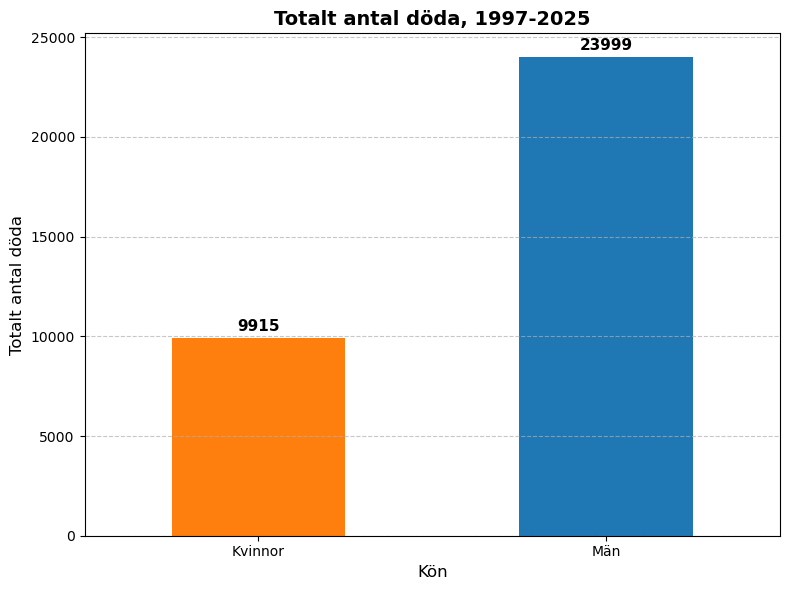

In [3]:
import matplotlib.pyplot as plt

# Kolla hur många män respektive kvinnor i datasetet
# Filtrera bort "Båda könen" så vi bara har 'Män' och 'Kvinnor' kvar.
totals = data_rows[data_rows['Kön'] != 'Båda könen']

# FIXEN: Tvinga 'Antal' att bli siffror. All text blir till tomma värden (NaN) som inte kraschar koden.
totals['Antal'] = pd.to_numeric(totals['Antal'], errors='coerce')

# 2. Gruppera efter 'Kön' och summera kolumnen 'Antal'.
totals = totals.groupby(['Kön'])['Antal'].sum().reset_index()

# Visa resultatet i tabellform (valfritt, men bra för kontroll)
print("Totalsummor för hela perioden (1997-2025):")
print(totals)


# Rita ett stapeldiagram
# sätter 'Kön' på x-axeln och 'Antal' på y-axeln.
ax = totals.plot(
    kind='bar', 
    x='Kön', 
    y='Antal', 
    rot=0,               # Gör så texten 'Män'/'Kvinnor' står rakt, inte snett
    legend=False,         # Vi behöver ingen teckenförklaring här
    figsize=(8, 6),      # Storlek på diagrammet
    color=['#ff7f0e', '#1f77b4'] # Orange för Kvinnor, Blå för Män (färgerna beror på sortering, justera vid behov)    
)

# Snygga till diagrammet med rubriker och rutnät
plt.title('Totalt antal döda, 1997-2025', fontsize=14, fontweight='bold')
plt.ylabel('Totalt antal döda', fontsize=12)
plt.xlabel('Kön', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Visa horisontella stödlinjer

# Lägg till siffror ovanpå staplarna
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



## Frågeställning: ##

Tittar vi på månadstrenden över självmord i sverige så ser den ut att variera kraftigt. Skulle vi kunna omfördela resurser baserat på månad eller säsong?

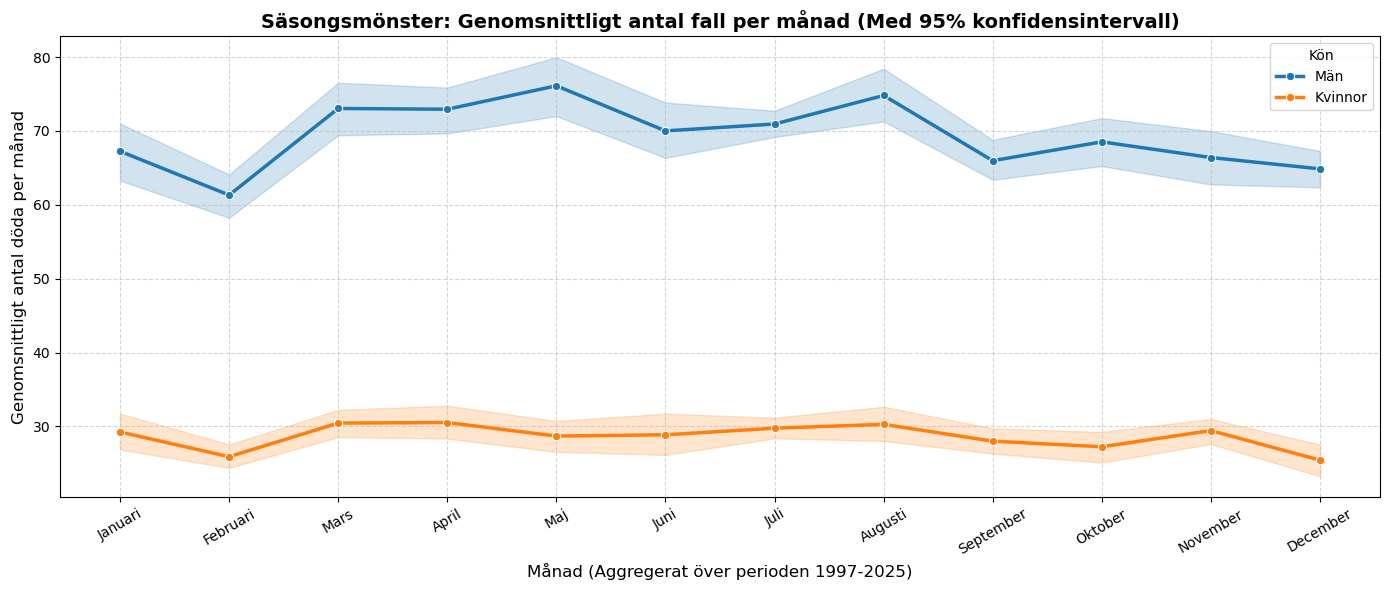

Kan se att Mars - Maj är högre och även Augusti
Går också att tyda att de är de ljusa månanderna är värre generellt. tvärt om vad man kan tro.


In [9]:
import seaborn as sns

# =====================================================================
# DEL 2: SÄSONGSANALYS FÖR BESLUTSFATTARE (Månadstrender & Pålitlighet)
# =====================================================================

# Säkerställ att vi har rätt dataformat (utgå från din 'långa' data)
# Vi filtrerar bort 'Båda könen' så vi ser skillnaden per månad för män och kvinnor
season_data = data_rows[data_rows['Kön'] != 'Båda könen'].copy()

# Tvinga Antal till siffror även här så inget skräp förstör beräkningen
season_data['Antal'] = pd.to_numeric(season_data['Antal'], errors='coerce')

# Skapa en kolumn med bara månadsnamnet (t.ex. 'January')
# (Om dina månader fortfarande innehåller år, t.ex. 'Januari 1997', 
# ser vi till att rensa bort årtalet så vi kan slå ihop alla januari-månader)
season_data['Månadsnamn'] = season_data['Månad'].str.split().str[0]

#  Sortera månaderna kronologiskt (Jan till Dec) så diagrammet inte sorteras alfabetiskt
månads_ordning = ['Januari', 'Februari', 'Mars', 'April', 'Maj', 'Juni', 
                  'Juli', 'Augusti', 'September', 'Oktober', 'November', 'December']

# Om din fil har engelska månadsnamn, ändra listan ovan till ['January', 'February'...]
season_data['Månadsnamn'] = pd.Categorical(season_data['Månadsnamn'], categories=månads_ordning, ordered=True)


# Rita diagram
plt.figure(figsize=(14, 6))

# sns.lineplot med errorbar=('ci', 95) räknar automatiskt ut konfidensintervallet 
# baserat på spridningen över alla år (1997-2025) och ritar det som ett skuggat fält.
sns.lineplot(
    data=season_data, 
    x='Månadsnamn', 
    y='Antal', 
    hue='Kön', 
    marker='o',
    errorbar=('ci', 95), # KRITERIUM: Statistisk verifiering (95% konfidensintervall)
    palette=['#1f77b4', '#ff7f0e'], # Matchar dina färger från stapeldiagrammet
    linewidth=2.5
)

# Snygga till diagrammet för presentation
plt.title('Säsongsmönster: Genomsnittligt antal fall per månad (Med 95% konfidensintervall)', fontsize=14, fontweight='bold')
plt.ylabel('Genomsnittligt antal döda per månad', fontsize=12)
plt.xlabel('Månad (Aggregerat över perioden 1997-2025)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30) # Lutar texten lite för bättre läsbarhet

plt.tight_layout()
plt.show()
print("Kan se att Mars - Maj är högre och även Augusti")
print("Går också att tyda att de är de ljusa månanderna är värre generellt. tvärt om vad man kan tro.")

In [12]:
import numpy as np

# 1. Gruppera data per Kön och Månadsnamn och räkna ut medelvärde, standardavvikelse och antal år
stats = season_data.groupby(['Kön', 'Månadsnamn'])['Antal'].agg(['mean', 'std', 'count']).reset_index()

# 2. Räkna ut standardfelet (SEM) och det 95%-iga konfidensintervallet (felmarginalen)
# Formel för 95% CI: 1.96 * (standardavvikelse / roten ur antalet observationer)
stats['felmarginal'] = 1.96 * (stats['std'] / np.sqrt(stats['count']))

# 3. Sortera så vi ser Män först, från Januari till December
stats = stats.sort_values(['Kön', 'Månadsnamn'])

# Skriv ut resultatet som en snygg tabell i terminalen
print("\nStatistiska siffror (Medelvärde och ± Felmarginal)")
pd.set_option('display.max_rows', None) # Se till att hela tabellen visas
print(stats[['Kön', 'Månadsnamn', 'mean', 'felmarginal']].to_string(index=False, formatters={'mean':'{:.1f}'.format, 'felmarginal':'{:.1f}'.format}))


Statistiska siffror (Medelvärde och ± Felmarginal)
    Kön Månadsnamn mean felmarginal
Kvinnor    Januari 29.2         2.4
Kvinnor   Februari 25.9         1.6
Kvinnor       Mars 30.4         1.9
Kvinnor      April 30.5         2.3
Kvinnor        Maj 28.7         2.2
Kvinnor       Juni 28.9         2.8
Kvinnor       Juli 29.8         1.4
Kvinnor    Augusti 30.3         2.3
Kvinnor  September 28.0         1.7
Kvinnor    Oktober 27.2         2.1
Kvinnor   November 29.4         1.7
Kvinnor   December 25.4         2.2
    Män    Januari 67.2         3.9
    Män   Februari 61.3         2.9
    Män       Mars 73.0         3.5
    Män      April 72.9         3.1
    Män        Maj 76.1         3.9
    Män       Juni 70.0         3.8
    Män       Juli 70.9         1.9
    Män    Augusti 74.8         3.7
    Män  September 66.0         2.8
    Män    Oktober 68.5         3.4
    Män   November 66.4         3.6
    Män   December 64.9         2.6


C:\Users\pheds\AppData\Local\Temp\ipykernel_19864\2618047630.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = season_data.groupby(['Kön', 'Månadsnamn'])['Antal'].agg(['mean', 'std', 'count']).reset_index()


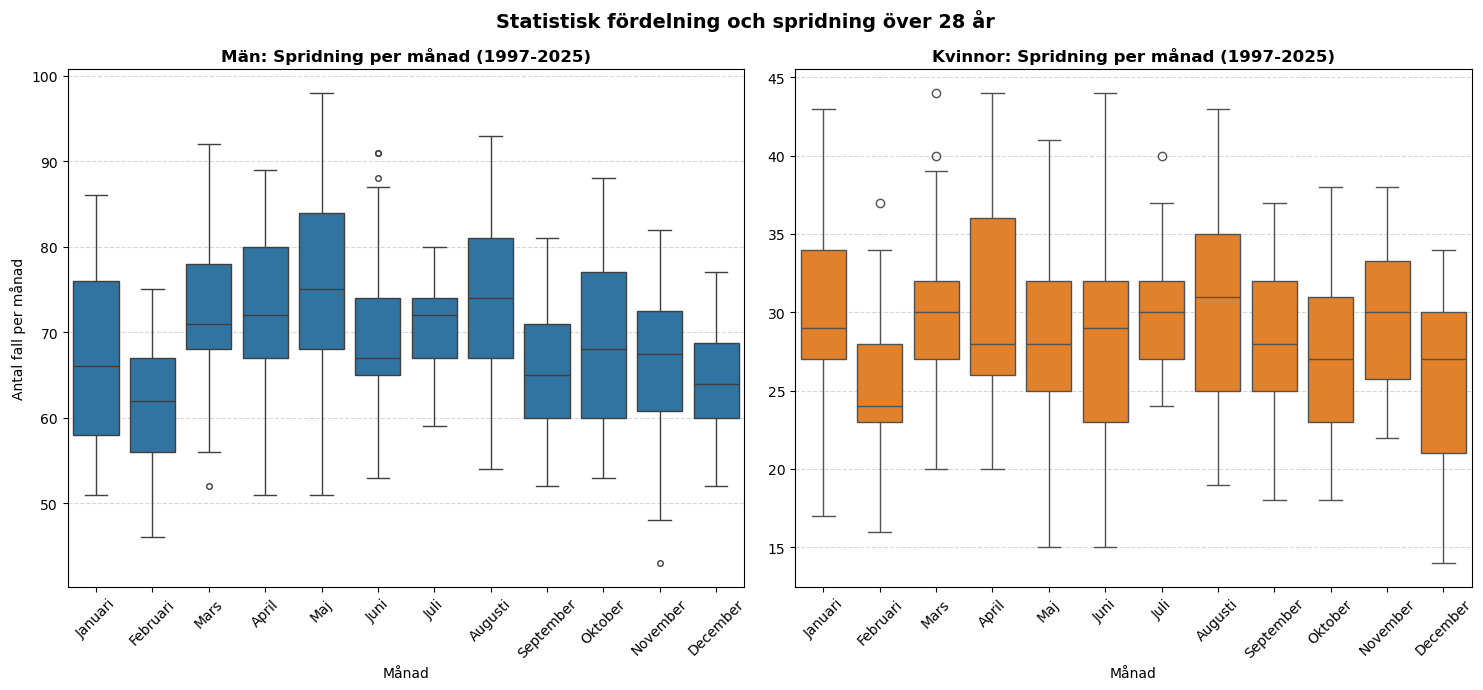

In [11]:
# --- RITA BOXPLOT-DIAGRAM ---
plt.figure(figsize=(15, 7))

# Vi skapar två subplots bredvid varandra: en för män och en för kvinnor
# Detta gör det mycket lättare att se spridningen utan att graferna krockar

# 1. Boxplot för MÄN
plt.subplot(1, 2, 1)
sns.boxplot(
    data=season_data[season_data['Kön'] == 'Män'], 
    x='Månadsnamn', 
    y='Antal', 
    color='#1f77b4',
    fliersize=4 # Storlek på eventuella "outliers" (extremår)
)
plt.title('Män: Spridning per månad (1997-2025)', fontsize=12, fontweight='bold')
plt.ylabel('Antal fall per månad')
plt.xlabel('Månad')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 2. Boxplot för KVINNOR
plt.subplot(1, 2, 2)
sns.boxplot(
    data=season_data[season_data['Kön'] == 'Kvinnor'], 
    x='Månadsnamn', 
    y='Antal', 
    color='#ff7f0e'
)
plt.title('Kvinnor: Spridning per månad (1997-2025)', fontsize=12, fontweight='bold')
plt.ylabel('') # Samma y-axel behövs inte skrivas igen
plt.xlabel('Månad')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Statistisk fördelning och spridning över 28 år', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats


# STATISTISK VERIFIERING MED ANOVA (Män vs Kvinnor)


print("\n=== STATISTISKT TEST (ANOVA) ===")

for kön in ['Män', 'Kvinnor']:
    # Skapa en lista med data för varje månad för det specifika könet
    # Vi samlar alla värden för Januari i en hög, Februari i en hög, osv.
    grupper = [
        season_data[(season_data['Kön'] == kön) & (season_data['Månadsnamn'] == månad)]['Antal'].dropna()
        for månad in månads_ordning
    ]
    
    # Kör ANOVA-testet (f_oneway jämför medelvärdena mellan alla 12 grupper)
    f_stat, p_val = stats.f_oneway(*grupper)
    
    # Presentera resultatet för beslutsfattaren
    print(f"\nResultat för {kön}:")
    print(f"  F-statistik: {f_stat:.2f}")
    print(f"  p-värde: {p_val:.5f}")
    
    if p_val < 0.05:
        print(f"  SLUTSATS: Skillnaden mellan månaderna är STATISTISKT SIGNIFIKANT (p < 0.05).")
        print(f"            'Puckeln' under året är inte en slump. Resurser BÖR omfördelas.")
    else:
        print(f"  SLUTSATS: Skillnaden är INTE statistiskt signifikant (p >= 0.05).")
        print(f"            Mönstret kan bero på slumpen. Omfördela INTE resurser baserat på tid.")


=== STATISTISKT TEST (ANOVA) ===

Resultat för Män:
  F-statistik: 6.77
  p-värde: 0.00000
  SLUTSATS: Skillnaden mellan månaderna är STATISTISKT SIGNIFIKANT (p < 0.05).
            'Puckeln' under året är inte en slump. Resurser BÖR omfördelas.

Resultat för Kvinnor:
  F-statistik: 2.56
  p-värde: 0.00398
  SLUTSATS: Skillnaden mellan månaderna är STATISTISKT SIGNIFIKANT (p < 0.05).
            'Puckeln' under året är inte en slump. Resurser BÖR omfördelas.


**Visualisering**